Calculated Ecological Tipping Point (ETP) for Inulin: ΔpH = -0.810


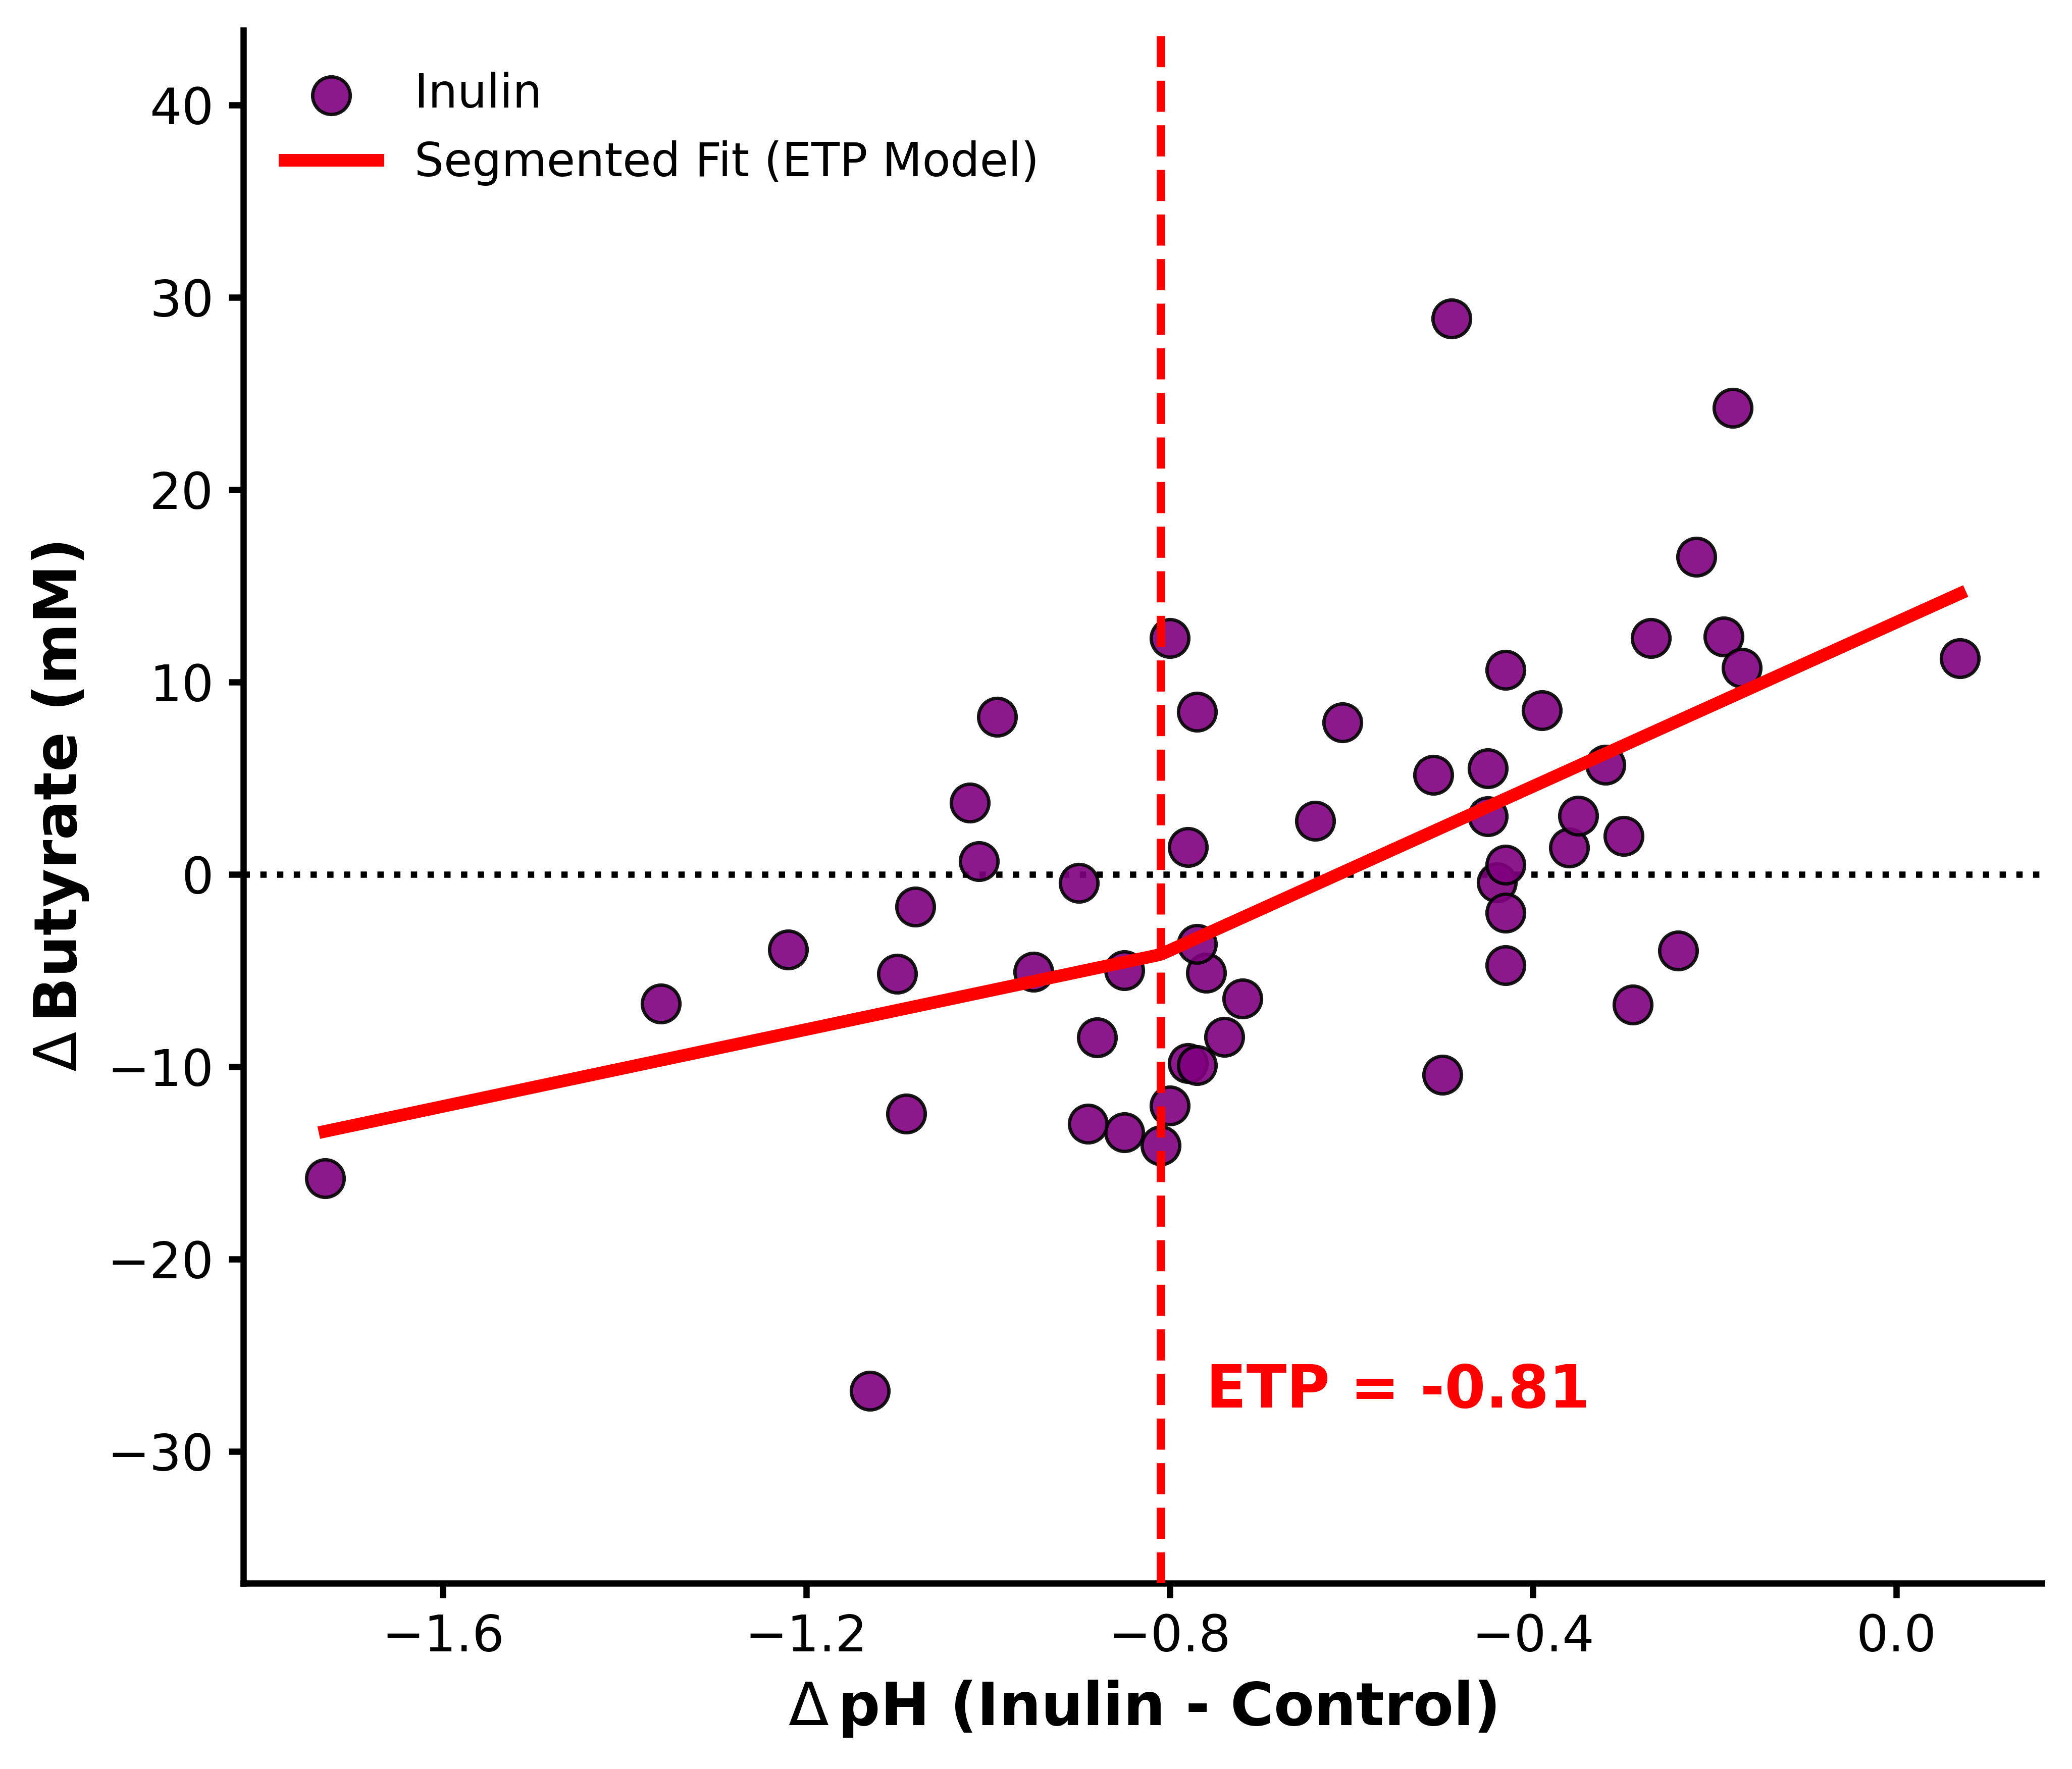

In [ ]:
"""
Segmented Regression Analysis for Ecological Tipping Point (ETP) of Inulin
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# Plotting Configuration (Nature Portfolio Standard)
# ---------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})
DPI_SETTING = 600

# ---------------------------------------------------------
# Data Loading and Parsing
# ---------------------------------------------------------
df_ph = pd.read_csv('pH.csv')
df_buty = pd.read_csv('Butyrate(mM).csv')
donors = [c for c in df_ph.columns if str(c).startswith('HS-')]

def get_raw_data(df: pd.DataFrame, target_id: str) -> pd.Series:
    """Extracts and cleans row data for a specific KULFFI substrate."""
    mask = df['KULFFI'].str.strip() == target_id
    if not mask.any():
        raise ValueError(f"Error: Target ID '{target_id}' not found in data.")
    s = df[mask][donors].iloc[0]
    s = s.astype(str).replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan)
    return pd.to_numeric(s, errors='coerce')

# Extract Control Data
ctrl_ph = get_raw_data(df_ph, 'Control')
ctrl_buty = get_raw_data(df_buty, 'Control')

# Extract Target Data (Inulin ONLY)
TARGET = 'Inulin'
d_ph = get_raw_data(df_ph, TARGET) - ctrl_ph
d_buty = get_raw_data(df_buty, TARGET) - ctrl_buty

# Combine and apply strictly Zero-Imputation Rule
df_inulin = pd.DataFrame({
    'Delta_pH': d_ph,
    'Delta_Butyrate': d_buty
}).dropna()

if df_inulin.empty:
    raise ValueError("Execution Aborted: No valid pairwise data remaining.")

# ---------------------------------------------------------
# Segmented (Piecewise) Linear Regression
# ---------------------------------------------------------
def piecewise_linear_bound(x, x0, y0, k1, k2):
    return np.where(x < x0, k1 * (x - x0) + y0, k2 * (x - x0) + y0)

bounds = ([-1.5, -50, 0, 0], [-0.2, 50, 100, 100])
p_guess = [-0.8, 0, 15, 15]

popt, pcov = curve_fit(
    piecewise_linear_bound,
    df_inulin['Delta_pH'],
    df_inulin['Delta_Butyrate'],
    p0=p_guess,
    bounds=bounds,
    maxfev=10000
)

etp_val = popt[0]
print(f"Calculated Ecological Tipping Point (ETP) for {TARGET}: ΔpH = {etp_val:.3f}")

# ---------------------------------------------------------
# Publication-Ready Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), dpi=DPI_SETTING)

# Baseline reference
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, zorder=1)

# Scatter plot for Inulin
sns.scatterplot(
    data=df_inulin,
    x='Delta_pH',
    y='Delta_Butyrate',
    color='#800080',
    label=TARGET,
    s=80,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
    ax=ax
)

# Plot the fitted Segmented Regression Line
x_line = np.linspace(df_inulin['Delta_pH'].min(), df_inulin['Delta_pH'].max(), 300)
y_line = piecewise_linear_bound(x_line, *popt)
ax.plot(x_line, y_line, color='red', linewidth=3, zorder=4, label='Segmented Fit (ETP Model)')

# Draw the statistical ETP threshold line
ax.axvline(etp_val, color='red', linestyle='--', linewidth=2, alpha=1.0, zorder=5)

# Axis configuration
ax.set_xlabel(r'$\Delta\,$pH (Inulin - Control)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\Delta\,$Butyrate (mM)', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.4))

# Set Dynamic Y-Limits
max_y = df_inulin['Delta_Butyrate'].max() + 15
min_y = df_inulin['Delta_Butyrate'].min() - 10
ax.set_ylim(min_y, max_y)

ax.text(
    etp_val + 0.05,       # Moved right by +0.05
    min_y + 10,
    f'ETP = {etp_val:.2f}',
    fontsize=14,
    fontweight='bold',
    color='red',
    ha='left',            # Left-aligned to extend rightwards
    va='center',
    zorder=6,
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
)

# Legend and Cleanup
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, frameon=False, loc='upper left', fontsize=11)
sns.despine(trim=False)
plt.tight_layout()

# Save output
output_file = f'Figure_7a.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')
plt.show()